In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#Data load 
import pandas as pd

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

#

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
'''
Rows: 7,043
Columns: 21
Target column: Churn
customerID → customer ki unique ID
Numerical columns → SeniorCitizen, tenure, MonthlyCharges, TotalCharges
Baaki kaafi columns categorical hain (Yes/No, Male/Female, contract types, etc.)
'''

'\nRows: 7,043\nColumns: 21\nTarget column: Churn\ncustomerID → customer ki unique ID\nNumerical columns → SeniorCitizen, tenure, MonthlyCharges, TotalCharges\nBaaki kaafi columns categorical hain (Yes/No, Male/Female, contract types, etc.)\n'

In [5]:
#data inspection print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: obje

In [6]:
#check Missing Values 
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
#check duplicates 
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
#describe  the data 
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [9]:
#Categorical values check
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].value_counts())


 customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

 gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

 Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

 Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

 PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

 MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

 InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

 OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

 OnlineBackup
OnlineBackup
No                     3088
Yes                

C:\Users\91703\AppData\Local\Temp\ipykernel_15028\870483104.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [10]:
#Churn distribution
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [11]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


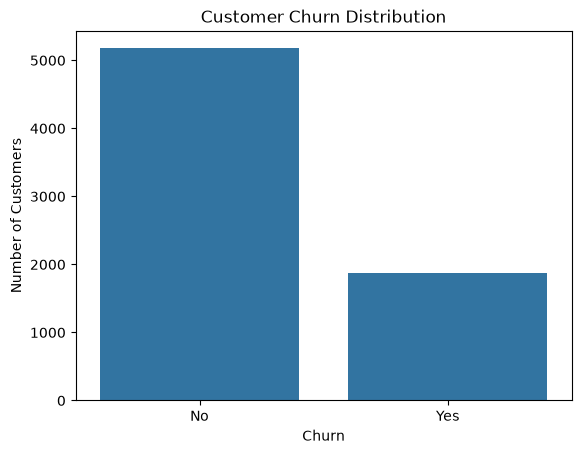

In [12]:
#EDA 
#step 1 Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

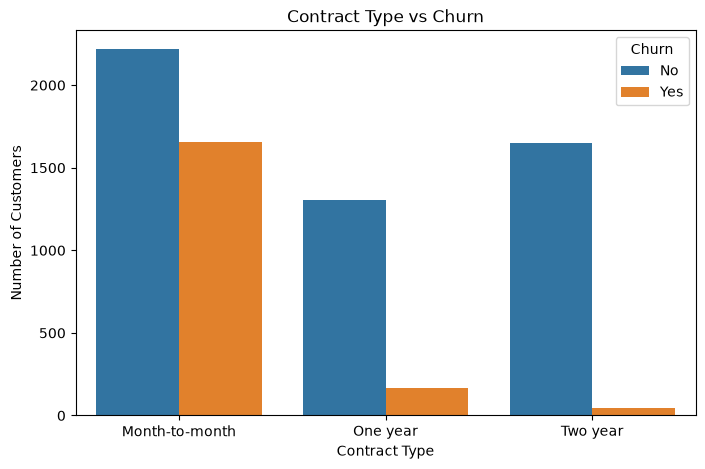

In [13]:
#Contract vs Churn
plt.figure(figsize=(8, 5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

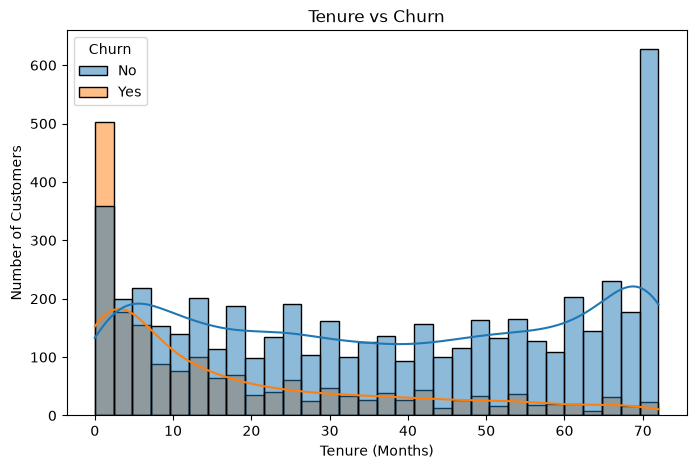

In [14]:
#Tenure vs Churn



plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)

plt.title("Tenure vs Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

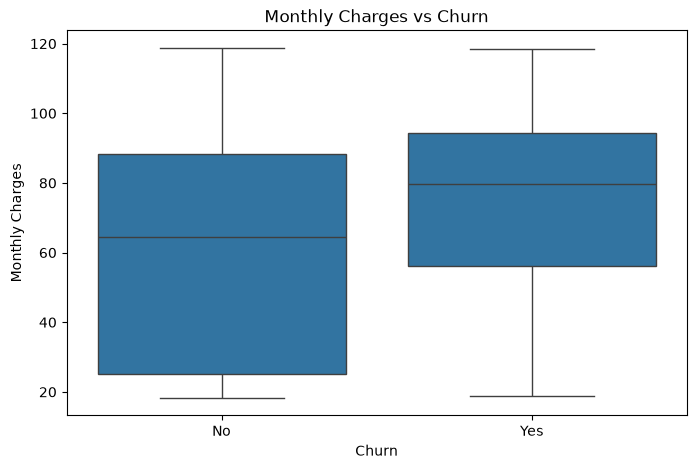

In [15]:
#Monthly Charges vs Churn

#Ab dekhte hain ki higher monthly charges wale customers mein churn zyada hai ya nahi.

plt.figure(figsize=(8, 5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [16]:
#Univariate Numerical Analysis



numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print(numerical_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')


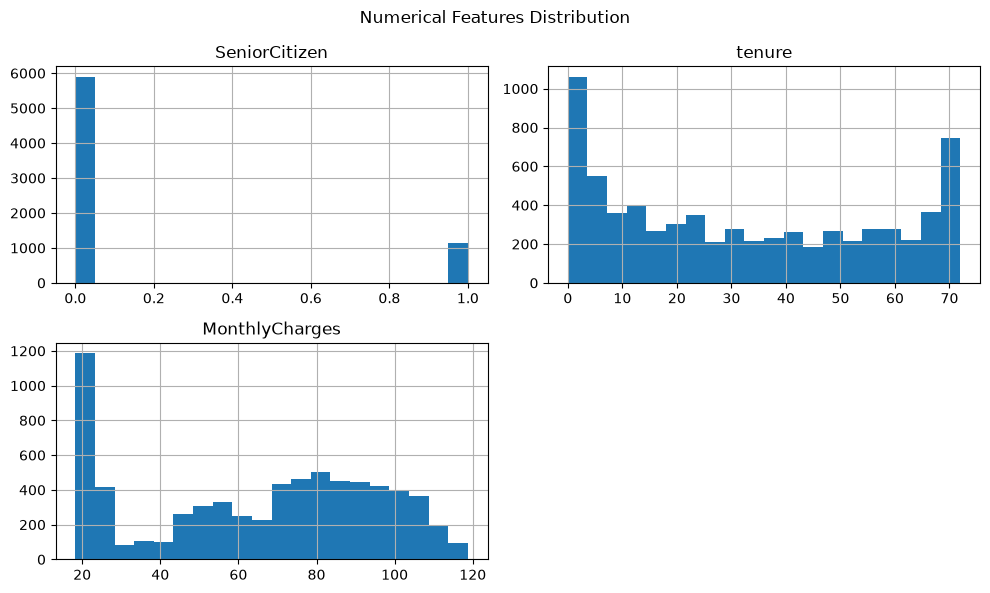

In [17]:
df[numerical_cols].hist(figsize=(10, 6), bins=20)

plt.suptitle("Numerical Features Distribution")
plt.tight_layout()
plt.show()

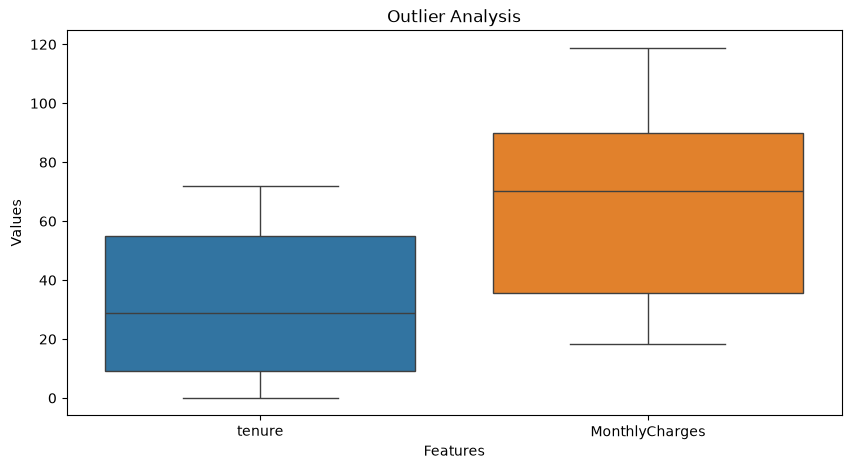

In [18]:
#Outliers 
plt.figure(figsize=(10, 5))

sns.boxplot(data=df[["tenure", "MonthlyCharges"]])

plt.title("Outlier Analysis")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

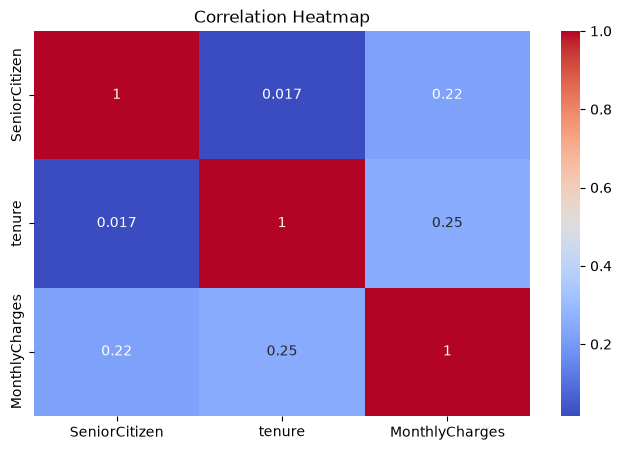

In [19]:
#Correlation Analysis / Heatmap 

#Ab hum numerical features ke beech relationship dekhenge.

correlation = df[["SeniorCitizen", "tenure", "MonthlyCharges"]].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [20]:
'''Final EDA Insights 

Ab tak jo analysis kiya hai usse hum important observations note karenge:

Churn: 26.54% customers churn kar rahe hain.
Contract: Contract type aur churn ke beech noticeable relationship hai.
Tenure: Newer customers mein churn ka pattern important hai.
Monthly Charges: Charges aur churn ke distribution mein difference hai.
Numerical features: tenure, MonthlyCharges, SeniorCitizen analyze ho chuke hain.
Data quality: duplicates nahi mile; lekin TotalCharges ke blank strings ko cleaning phase mein specifically check karna hai.'''

'Final EDA Insights \n\nAb tak jo analysis kiya hai usse hum important observations note karenge:\n\nChurn: 26.54% customers churn kar rahe hain.\nContract: Contract type aur churn ke beech noticeable relationship hai.\nTenure: Newer customers mein churn ka pattern important hai.\nMonthly Charges: Charges aur churn ke distribution mein difference hai.\nNumerical features: tenure, MonthlyCharges, SeniorCitizen analyze ho chuke hain.\nData quality: duplicates nahi mile; lekin TotalCharges ke blank strings ko cleaning phase mein specifically check karna hai.'

In [21]:
#Data Cleaning
#TotalCharges check


print("Blank TotalCharges:",
      df["TotalCharges"].astype(str).str.strip().eq("").sum())

Blank TotalCharges: 11


In [22]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].isnull().sum())

11


In [23]:
df = df.dropna(subset=["TotalCharges"])

print("Shape after cleaning:", df.shape)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Shape after cleaning: (7032, 21)
Missing TotalCharges: 0


In [24]:
#Check dataTypes
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [25]:
#Clean customerIDs
df = df.drop("customerID", axis=1)

print(df.shape)
print(df.columns)

(7032, 20)
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [26]:
#Target Encoding



#Model ko numerical values chahiye, isliye No → 0 aur Yes → 1 karenge.

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df["Churn"].value_counts())
print(df["Churn"].dtype)

Churn
0    5163
1    1869
Name: count, dtype: int64
int64


In [27]:
#Feature Encoding

'''Ab problem ye hai ki hamare bahut saare features text/categorical hain, jaise:

gender, Partner, Contract, InternetService, PaymentMethod etc.

ML model directly in text values ko understand nahi karega.

Isliye next hum categorical features ko numerical format mein convert karenge using One-Hot Encoding.

Pehle identify karte hain ki kitne categorical columns bache hain:'''

categorical_cols = df.select_dtypes(include=["object", "str"]).columns

print(categorical_cols)
print("Total categorical columns:", len(categorical_cols))

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')
Total categorical columns: 15


In [28]:
#Seperate X and Y 
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [29]:


#We were at Train/Test Split. Since you've already separated X and y, run this:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

'''Why stratify=y?

Our target has:

73.46% → No Churn
26.54% → Churn

stratify=y keeps approximately the same churn ratio in both training and testing data.'''

X_train: (5625, 19)
X_test: (1407, 19)
y_train: (5625,)
y_test: (1407,)


'Why stratify=y?\n\nOur target has:\n\n73.46% → No Churn\n26.54% → Churn\n\nstratify=y keeps approximately the same churn ratio in both training and testing data.'

In [30]:
'''One-Hot Encoding

Now we need to convert the 15 categorical columns into numerical columns.

We'll use OneHotEncoder through a ColumnTransformer. This is better than manually encoding because it keeps the preprocessing organized and prevents data leakage.
'''

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(include=["object", "str"]).columns
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("X_train encoded shape:", X_train_encoded.shape)
print("X_test encoded shape:", X_test_encoded.shape)

#We fit only on training data. This is an important ML practice to avoid data leakage.

X_train encoded shape: (5625, 45)
X_test encoded shape: (1407, 45)


In [31]:
#Next — Check the encoded data

#Before training a model, let's verify the final feature size:

print("Original features:", X_train.shape[1])
print("Encoded features:", X_train_encoded.shape[1])

Original features: 19
Encoded features: 45


In [32]:
#It means your current X_train has 45 columns/features.

#But earlier we expected 19 from the original dataset, so something has likely changed in your notebook. Before moving to model training, let's verify exactly what is inside X_train.
print(X_train.shape)
print(X_train.columns.tolist())
#Original data → 19 features → One-Hot Encoding → 48 features

(5625, 19)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [33]:
#Model Train Parts
#Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)

print(y_pred[:10])

[0 1 0 0 0 0 0 0 1 0]


In [34]:
#Logistic Regression evaluation

'''
Accuracy
Confusion Matrix
Precision / Recall / F1
ROC-AUC
'''

'\nAccuracy\nConfusion Matrix\nPrecision / Recall / F1\nROC-AUC\n'

In [35]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8038379530916845


In [36]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [37]:
#confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[915 118]
 [158 216]]


In [38]:
#explanation 
'''Isko hum 4 parts mein read karte hain:

Actual	Predicted	        Count	      Meaning
0	        0	            915	          Correct  No Churn → TN
0	 	    1               118	          Wrongly predicted Churn → FP
1		    0               158	          Churn customer miss ho gaya → FN
1		    1               216	          Correctly predicted Churn → TP'''

'Isko hum 4 parts mein read karte hain:\n\nActual\tPredicted\t        Count\t      Meaning\n0\t        0\t            915\t          Correct  No Churn → TN\n0\t \t    1               118\t          Wrongly predicted Churn → FP\n1\t\t    0               158\t          Churn customer miss ho gaya → FN\n1\t\t    1               216\t          Correctly predicted Churn → TP'

In [39]:

'''
Ab Logistic Regression ka conclusion

Accuracy = 80%
Churn Recall = 58%
Churn F1 = 61%
'''

'\nAb Logistic Regression ka conclusion\n\nAccuracy = 80%\nChurn Recall = 58%\nChurn F1 = 61%\n'

In [40]:
#Step — ROC-AUC
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_encoded)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

#like [:, 1] ka matlab hai Churn = 1 ki probability.


#explanation 
'''Ye Logistic Regression ke liye strong baseline hai.

ROC-AUC ka simple meaning

ROC-AUC basically check karta hai ki model Churn (1) aur No Churn (0) customers ko kitna achhe se distinguish kar pa raha hai.

0.5 -> random guessing
0.6 ->0.7 → weak
0.7 ->0.8 → decent
0.8 ->0.9 → good
0.9+ → excellent'''


#conclusion of LogisticRegression
'''Accuracy   = 80%
Precision  = 65%  (Churn)
Recall     = 58%  (Churn)
F1-score   = 61%  (Churn)
ROC-AUC    = 0.8358'''

ROC-AUC: 0.8358695145751692


'Accuracy   = 80%\nPrecision  = 65%  (Churn)\nRecall     = 58%  (Churn)\nF1-score   = 61%  (Churn)\nROC-AUC    = 0.8358'

In [41]:
#KNN 

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

X_train_knn = preprocessor_knn.fit_transform(X_train)
X_test_knn = preprocessor_knn.transform(X_test)

print("Training shape:", X_train_knn.shape)
print("Testing shape:", X_test_knn.shape)

#Scaling + preprocessing successfully done.

Training shape: (5625, 45)
Testing shape: (1407, 45)


In [42]:
# KNN model, k=5
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_knn, y_train)

y_pred_knn = knn_model.predict(X_test_knn)

print(y_pred_knn[:10])

[0 1 0 0 0 0 0 0 1 0]


In [43]:
#Accuracy and Classification
from sklearn.metrics import accuracy_score, classification_report

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7619047619047619

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.55      0.58      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.76      0.76      1407



[[854 179]
 [156 218]]


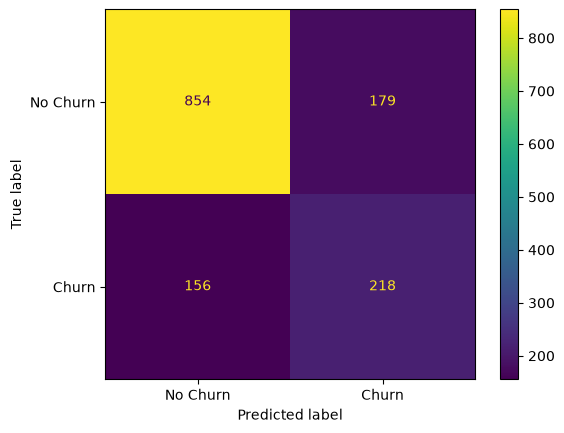

'\nTN = 854 → correctly predicted No Churn\nFP = 179 → No Churn ko Churn predict kiya\nFN = 156 → Churn customer ko No Churn predict kiya ⚠️\nTP = 218 → correctly predicted Churn\n\nChurn recall = 218 / (218 + 156) ≈ 58%, jo classification report se match karta hai. \n'

In [44]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.show()

'''
TN = 854 → correctly predicted No Churn
FP = 179 → No Churn ko Churn predict kiya
FN = 156 → Churn customer ko No Churn predict kiya ⚠️
TP = 218 → correctly predicted Churn

Churn recall = 218 / (218 + 156) ≈ 58%, jo classification report se match karta hai. 
'''

In [45]:
#ROC - AUC
from sklearn.metrics import roc_auc_score

y_prob_knn = knn_model.predict_proba(X_test_knn)[:, 1]

roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

print("KNN ROC-AUC:", roc_auc_knn)

KNN ROC-AUC: 0.7798789673398181


In [46]:
#quick summary


#KNN Final Result

'''Accuracy: 76.19%
Churn Recall: 58%
Churn F1: 57%
ROC-AUC: ~0.77'''


#🆚 Current Comparison
'''
| Model               | Accuracy | Churn Recall |      F1 |   ROC-AUC |
| ------------------- | -------: | -----------: | ------: | --------: |
| Logistic Regression |  **80%** |          58% | **61%** | **0.836** |
| KNN                 |   76.19% |          58% |     57% |     ~0.77 |
'''

#So KNN is currently weaker than Logistic Regression.

'\n| Model               | Accuracy | Churn Recall |      F1 |   ROC-AUC |\n| ------------------- | -------: | -----------: | ------: | --------: |\n| Logistic Regression |  **80%** |          58% | **61%** | **0.836** |\n| KNN                 |   76.19% |          58% |     57% |     ~0.77 |\n'

In [47]:
#KNN tuning with different K values

In [48]:
k_values = [3, 5, 7, 9, 11]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)

    y_pred = knn.predict(X_test_knn)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"K = {k}, Accuracy = {accuracy:.4f}")


'''
Observation
K=3 → 75.62%
K=5 → 76.19%
K=7 → 76.05%
K=9 → 77.26% ⭐ Best
K=11 → 76.83%
'''

K = 3, Accuracy = 0.7562
K = 5, Accuracy = 0.7619
K = 7, Accuracy = 0.7605
K = 9, Accuracy = 0.7726
K = 11, Accuracy = 0.7683


'\nObservation\nK=3 → 75.62%\nK=5 → 76.19%\nK=7 → 76.05%\nK=9 → 77.26% ⭐ Best\nK=11 → 76.83%\n'

In [49]:
#Final KNN Model
knn_model = KNeighborsClassifier(n_neighbors=9)

knn_model.fit(X_train_knn, y_train)

y_pred_knn = knn_model.predict(X_test_knn)

print("Final KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))

Final KNN Accuracy: 0.7725657427149965


In [50]:
# Implementation of Decision TREE

'''
                 Contract?
                /         \
          Month-to-month   2 year
              /              \
        High Charges?       No Churn
          /    \
        Yes     No
       Churn   No Churn
'''

'''
Important terms:

Root → first decision
Node → decision/question
Branch → decision ka outcome
Leaf → final prediction
Gini Impurity → split ki purity measure karta hai

'''

'\nImportant terms:\n\nRoot → first decision\nNode → decision/question\nBranch → decision ka outcome\nLeaf → final prediction\nGini Impurity → split ki purity measure karta hai\n\n'

In [51]:
#Decision Tree Modelfrom sklearn.tree import DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_encoded, y_train)

y_pred_dt = dt_model.predict(X_test_encoded)

print(y_pred_dt[:10])

[0 0 0 0 0 1 0 0 1 0]


In [52]:
#Accuracy + Classification Report:

from sklearn.metrics import accuracy_score, classification_report

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


'''
Result
Accuracy: 72.21%
Churn Precision: 48%
Churn Recall: 49%
Churn F1: 49%'''

Decision Tree Accuracy: 0.7221037668798863

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1033
           1       0.48      0.49      0.49       374

    accuracy                           0.72      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.72      0.72      1407



'\nResult\nAccuracy: 72.21%\nChurn Precision: 48%\nChurn Recall: 49%\nChurn F1: 49%'

[[831 202]
 [189 185]]


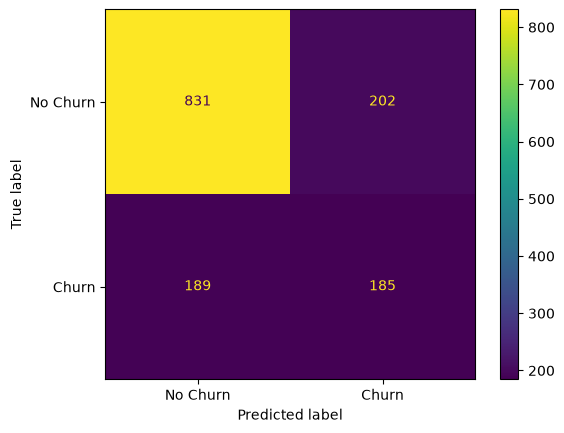

In [53]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.show()

In [54]:
#ROC- AUC
from sklearn.metrics import roc_auc_score

y_prob_dt = dt_model.predict_proba(X_test_encoded)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC-AUC:", roc_auc_dt)

Decision Tree ROC-AUC: 0.6497921530664541


In [55]:
#comparision
'''
| Model               |   Accuracy | Churn Recall | Churn F1 |   ROC-AUC |
| ------------------- | ---------: | -----------: | -------: | --------: |
| Logistic Regression | **80.00%** |          58% |  **61%** | **0.836** |
| KNN (K=9)           |     77.26% |          58% |      57% |     ~0.77 |
| Decision Tree       |     72.21% |          49% |      49% |  **0.64** |
'''

'\n| Model               |   Accuracy | Churn Recall | Churn F1 |   ROC-AUC |\n| ------------------- | ---------: | -----------: | -------: | --------: |\n| Logistic Regression | **80.00%** |          58% |  **61%** | **0.836** |\n| KNN (K=9)           |     77.26% |          58% |      57% |     ~0.77 |\n| Decision Tree       |     72.21% |          49% |      49% |  **0.64** |\n'

In [56]:
#max_depth experiment
depths = [3, 5, 7, 10, None]

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train_encoded, y_train)

    y_pred = dt.predict(X_test_encoded)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"max_depth = {depth}, Accuracy = {accuracy:.4f}")

max_depth = 3, Accuracy = 0.7783
max_depth = 5, Accuracy = 0.7896
max_depth = 7, Accuracy = 0.7775
max_depth = 10, Accuracy = 0.7555
max_depth = None, Accuracy = 0.7221


In [57]:
#result
'''
| Max Depth |      Accuracy |
| --------: | ------------: |
|         3 |        77.83% |
|     **5** | **78.96% 🏆** |
|         7 |        77.75% |
|        10 |        75.55% |
|      None |        72.21% |

'''

'\n| Max Depth |      Accuracy |\n| --------: | ------------: |\n|         3 |        77.83% |\n|     **5** | **78.96% 🏆** |\n|         7 |        77.75% |\n|        10 |        75.55% |\n|      None |        72.21% |\n\n'

In [58]:
'''
What did we learn?
max_depth=None → tree bahut deep gaya → overfitting ka risk → 72.21%
Depth increase karte hue performance pehle improve hui.
Depth = 5 par best accuracy: 78.96%
Uske baad depth badhne par accuracy decrease hone lagi.

So, abhi ke experiment ke according:

Best Decision Tree depth = 5'''

'\nWhat did we learn?\nmax_depth=None → tree bahut deep gaya → overfitting ka risk → 72.21%\nDepth increase karte hue performance pehle improve hui.\nDepth = 5 par best accuracy: 78.96%\nUske baad depth badhne par accuracy decrease hone lagi.\n\nSo, abhi ke experiment ke according:\n\nBest Decision Tree depth = 5'

In [59]:
#Final Decision Tree

#then train with the value of  max_depth=5 .

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train_encoded, y_train)

y_pred_dt = dt_model.predict(X_test_encoded)

print("Final Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Final Decision Tree Accuracy: 0.7896233120113717


In [60]:
#classificatin report
from sklearn.metrics import classification_report

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1033
           1       0.60      0.61      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



In [61]:
'''
Decision Tree — Final Interpretation
Accuracy: 78.96%
Class 0 (No Churn):
Precision: 86%
Recall: 85%
F1: 86%
Class 1 (Churn):
Precision: 60%
Recall: 61%
F1: 61%
'''

'\nDecision Tree — Final Interpretation\nAccuracy: 78.96%\nClass 0 (No Churn):\nPrecision: 86%\nRecall: 85%\nF1: 86%\nClass 1 (Churn):\nPrecision: 60%\nRecall: 61%\nF1: 61%\n'

[[881 152]
 [144 230]]


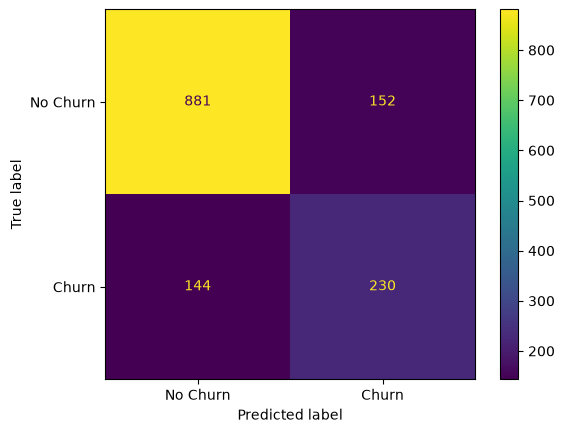

'\nMeaning:\n\nTN = 881 → actual No Churn, predicted No Churn\nFP = 152 → actual No Churn, predicted Churn\nFN = 144 → actual Churn, predicted No Churn\nTP = 230 → actual Churn, predicted Churn'

In [62]:
#confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.show()


'''
Meaning:

TN = 881 → actual No Churn, predicted No Churn
FP = 152 → actual No Churn, predicted Churn
FN = 144 → actual Churn, predicted No Churn
TP = 230 → actual Churn, predicted Churn'''

In [63]:
#ROC-AUC at maxdepth =5
from sklearn.metrics import roc_auc_score

y_prob_dt = dt_model.predict_proba(X_test_encoded)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC-AUC:", roc_auc_dt)

Decision Tree ROC-AUC: 0.8296250472379394


In [64]:
'''
Decision  Tree final result
| Metric          |     Result |
| --------------- | ---------: |
| Max Depth       |      **5** |
| Accuracy        | **78.96%** |
| Churn Precision |        60% |
| Churn Recall    |    **61%** |
| Churn F1        |    **61%** |
| ROC-AUC         |  **0.830** |
'''

'\nDecision  Tree final result\n| Metric          |     Result |\n| --------------- | ---------: |\n| Max Depth       |      **5** |\n| Accuracy        | **78.96%** |\n| Churn Precision |        60% |\n| Churn Recall    |    **61%** |\n| Churn F1        |    **61%** |\n| ROC-AUC         |  **0.830** |\n'

In [65]:
#Final comparision
'''
| Model                   |   Accuracy | Churn Recall | Churn F1 |   ROC-AUC |
| ----------------------- | ---------: | -----------: | -------: | --------: |
| Logistic Regression     | **80.00%** |          58% |  **61%** | **0.836** |
| KNN (K=9)               |     77.26% |          58% |      57% |     ~0.77 |
| Decision Tree (depth=5) |     78.96% |      **61%** |  **61%** | **0.830** |
'''


'\n| Model                   |   Accuracy | Churn Recall | Churn F1 |   ROC-AUC |\n| ----------------------- | ---------: | -----------: | -------: | --------: |\n| Logistic Regression     | **80.00%** |          58% |  **61%** | **0.836** |\n| KNN (K=9)               |     77.26% |          58% |      57% |     ~0.77 |\n| Decision Tree (depth=5) |     78.96% |      **61%** |  **61%** | **0.830** |\n'

In [66]:
#Random Forest Concept

#Random Forest = collection of multiple Decision Trees.

'''Ek single Decision Tree prediction deta hai:

Decision Tree 1 → Churn'''
#In random Forest
'''
Tree 1 → Churn
Tree 2 → No Churn
Tree 3 → Churn
Tree 4 → Churn
Tree 5 → Churn

        ↓

Majority Voting

        ↓

      Churn
'''



'''
Important parameter

n_estimators = forest mein kitne decision trees honge.

For example:

RandomForestClassifier(n_estimators=100)

means approximately 100 trees.
'''


#Model Train

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

y_pred_rf = rf_model.predict(X_test_encoded)

print(y_pred_rf[:10])

[0 1 0 0 0 0 0 0 1 0]


In [ ]:
#Accuracy + Classification
from sklearn.metrics import accuracy_score, classification_report

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))



'''
Random Forest — Baseline
Accuracy: 79.25%
Class 0 recall: 90%
Class 1 (Churn) recall: 51%
Churn F1: 57%'''

Random Forest Accuracy: 0.7924662402274343

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



[[925 108]
 [184 190]]


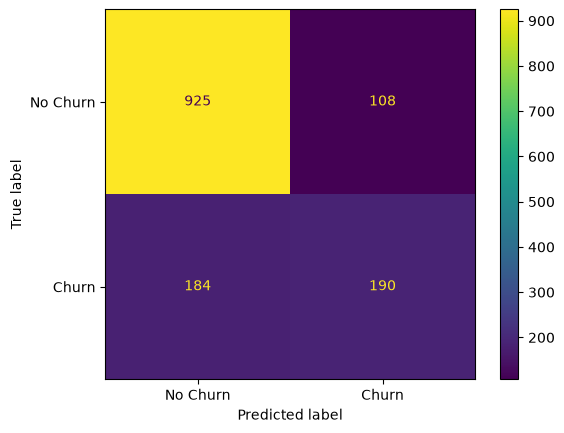

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.show()



'''
TN = 925 → correctly predicted No Churn
FP = 108 → No Churn predicted as Churn
FN = 184 → Churn predicted as No Churn
TP = 190 → correctly predicted Churn
'''

In [69]:
#ROC- AUC
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test_encoded)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.8129701145617095


In [ ]:
#comparision
'''
| Model                   |   Accuracy | Churn Recall | Churn F1 | ROC-AUC |
| ----------------------- | ---------: | -----------: | -------: | ------: |
| Logistic Regression     |     80.00% |          58% |      61% |   0.836 |
| KNN (K=9)               |     77.26% |          58% |      57% |   ~0.77 |
| Decision Tree (depth=5) |     78.96% |      **61%** |  **61%** |   0.830 |
| Random Forest           | **79.25%** |          51% |      57% |   0.810 |

'''

In [ ]:
# n _ estimators experiment
estimators = [50, 100, 200]

for n in estimators:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf.fit(X_train_encoded, y_train)

    y_pred = rf.predict(X_test_encoded)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"n_estimators = {n}, Accuracy = {accuracy:.4f}")


    #result
    '''
|   Trees |   Accuracy |
| ------: | ---------: |
|      50 |     78.89% |
| **100** | **79.25%** |
|     200 |     78.68% |

    '''

n_estimators = 50, Accuracy = 0.7889
n_estimators = 100, Accuracy = 0.7925
n_estimators = 200, Accuracy = 0.7868


In [71]:
#Final random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

y_pred_rf = rf_model.predict(X_test_encoded)

print("Final Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Final Random Forest Accuracy: 0.7924662402274343


In [ ]:
#final ROC-AUC

from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test_encoded)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Final Random Forest ROC-AUC:", roc_auc_rf)



#Result
'''
| Metric          | Random Forest |
| --------------- | ------------: |
| `n_estimators`  |           100 |
| Accuracy        |    **79.25%** |
| Churn Precision |           64% |
| Churn Recall    |           51% |
| Churn F1        |           57% |
| ROC-AUC         |      **0.81** |
'''

Final Random Forest ROC-AUC: 0.8129701145617095


In [ ]:
#comparison
'''
| Model                   |   Accuracy | Churn Recall | Churn F1 |   ROC-AUC |
| ----------------------- | ---------: | -----------: | -------: | --------: |
| Logistic Regression     | **80.00%** |          58% |      61% | **0.836** |
| KNN (K=9)               |     77.26% |          58% |      57% |     ~0.77 |
| Decision Tree (depth=5) |     78.96% |      **61%** |  **61%** |     0.830 |
| Random Forest (100)     |     79.25% |          51% |      57% |     0.810 |
'''